In [1]:
import numpy as np
from matplotlib import pyplot as plt
import astropy.coordinates as coord
import astropy.units as u
from astropy.coordinates import (SkyCoord, HeliocentricMeanEcliptic)


In [2]:
coords_TRAPPIST_1b = '23 06 29.3600 -05 02 29.20'
coords_WD1202_232 = '12 05 26.7211 -23 33 8.63'
coords_WD2105_82 = '21 13 18.7737 -81 49 18.77'
coords_WD1620_391 = '16 23 33.9413 -39 13 46.15'
coords_WD2149_02 = '21 52 25.3948 +02 23 14.92'
coords_IC_1613 = '01 05 1.4616 +02 09 11.66'
coords_SEXTANS_A = '10 11 6.4000 -04 42 17.66'
coords_GJ_3473 = '08 02 22.4521 +03 20 13.60'
coords_GJ_357 = '09 36 1.7964 -21 39 54.72'
coords_HD_260655 = '06 37 9.9436 +17 33 58.74'
coords_L_98_59 = '08 18 7.8951 -68 18 52.25'
coords_LHS_1140 = '00 44 59.6827 -15 16 27.09'
coords_LHS_1478 = '02 57 21.4288 +76 33 4.86'
coords_LTT_3780 = '10 18 34.7652 -11 43 4.21'
coords_TOI_1468 = '01 06 36.9279 +19 13 29.60'
coords_L_231_32 = '04 33 39.8638 -51 57 26.75'

In [3]:
target_coords = [coords_TRAPPIST_1b, coords_WD1202_232, coords_WD2105_82, coords_WD1620_391, coords_WD2149_02, 
                 coords_IC_1613, coords_SEXTANS_A, coords_GJ_3473, coords_GJ_357, coords_HD_260655, coords_L_98_59, 
                 coords_LHS_1140, coords_LHS_1478, coords_LTT_3780, coords_TOI_1468, coords_L_231_32]

In [4]:
# coords targets
coords = SkyCoord(target_coords[:], unit=(u.hourangle, u.deg))

In [5]:
target_names = ['TRAPPIST-1b', 'WD1202-232', 'WD2105-82', 'WD1620-391', 'WD2149+02', 'IC-1613', 'SEXTANS-A', 
                'GJ-3473', 'GJ-357', 'HD-260655', 'L-98-59', 'LHS-1140', 'LHS-1478', 'LTT-3780', 'TOI-1468', 'L-231-32']

In [6]:
# dibujar ecliptica
ecl_deg = np.array([(0, i) for i in np.linspace(0,360,500)])

In [7]:
# pasar a RA Dec
to_eq = np.zeros(ecl_deg.shape)

for i in range(len(ecl_deg)):
    RA = np.arctan2(np.sin(np.radians(ecl_deg[i,1])) * np.cos(np.radians(23.4)),np.cos(np.radians(ecl_deg[i,1])))
    dec = np.arcsin(np.sin(np.radians(ecl_deg[i,1])) * np.sin(np.radians(23.4)))
    to_eq[i] = RA,dec

In [8]:
ecl_coords = SkyCoord(to_eq[:], unit=(u.rad, u.rad))

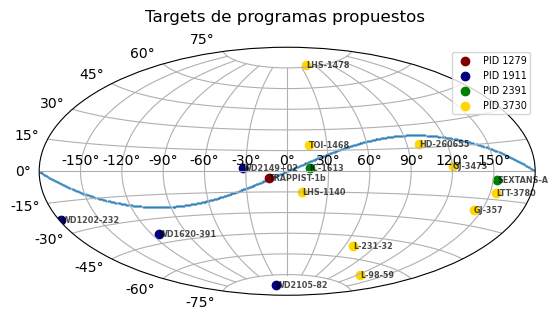

In [28]:
plt.subplot(111, projection='aitoff')
plt.title('Targets de programas propuestos \n')
plt.grid(True)
plt.scatter(ecl_coords.ra.wrap_at('180d').radian, ecl_coords.dec.radian,s=0.2)
plt.scatter(coords.ra.wrap_at('180d').radian[0], coords.dec.radian[0], color='maroon', label='PID 1279')
plt.scatter(coords.ra.wrap_at('180d').radian[1:5], coords.dec.radian[1:5], color='navy', label='PID 1911')
plt.scatter(coords.ra.wrap_at('180d').radian[5:7], coords.dec.radian[5:7], color='green', label='PID 2391')
plt.scatter(coords.ra.wrap_at('180d').radian[7:], coords.dec.radian[7:], color='gold', label='PID 3730')

for i, txt in enumerate(target_names):
    plt.annotate(txt, (coords.ra.wrap_at('180d').radian[i], coords.dec.radian[i]),
                 color='k', ha='left', va = 'center', weight = 'bold', size = 'xx-small',alpha = 0.7)

plt.legend(fontsize = 'x-small')